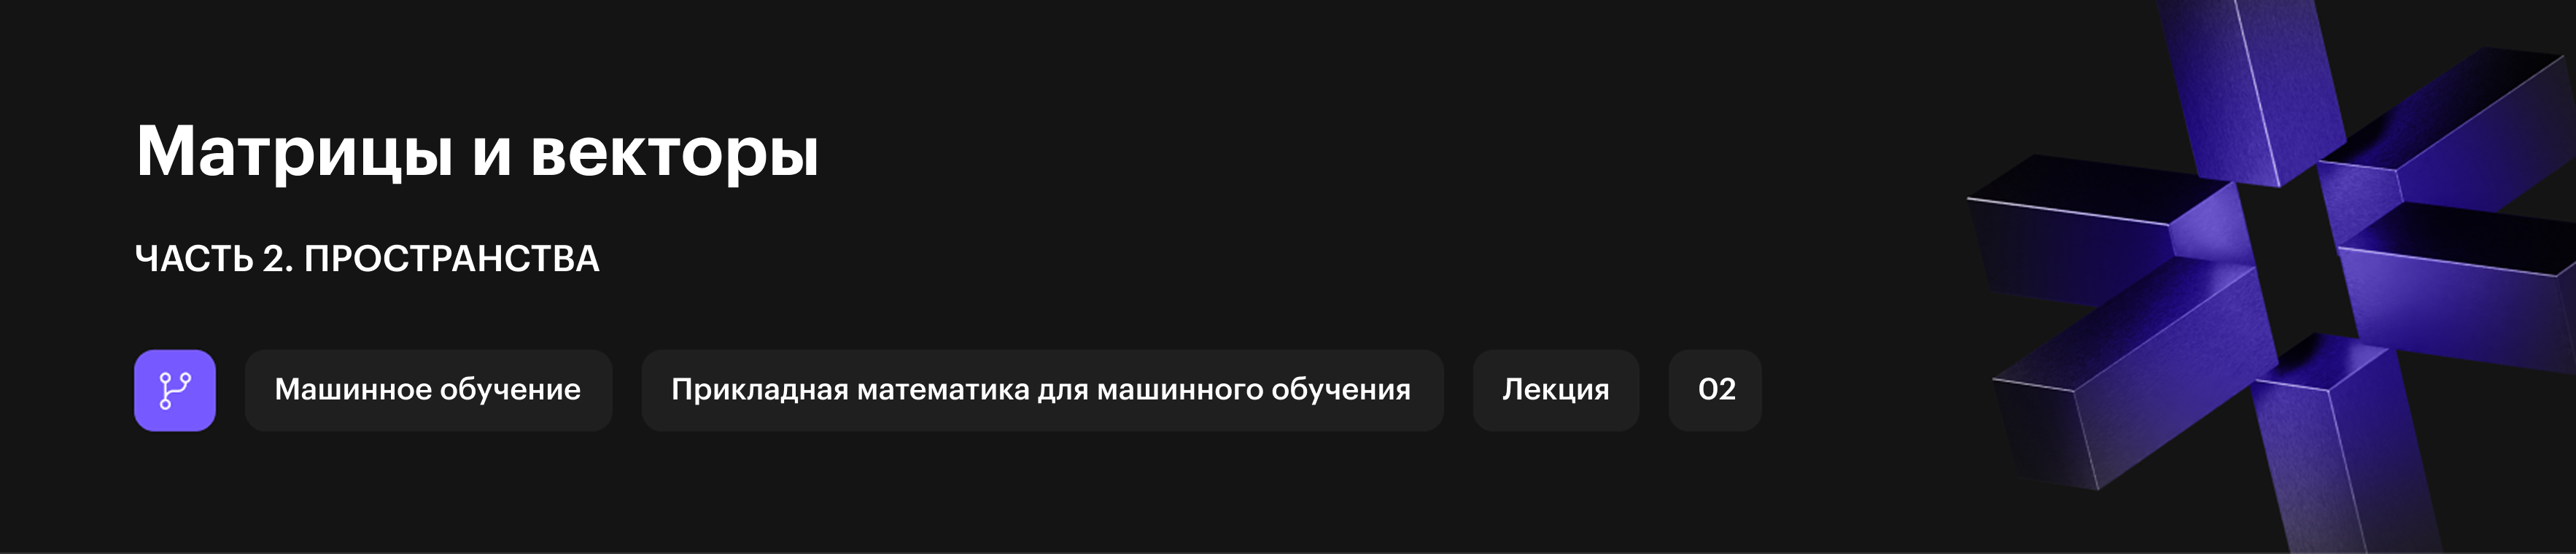

# Неделя 2. Матрицы и векторы (продолжение). Метрика и норма

Рассмотрим пример, как применяется пройденный нами на этой неделе материал в машинном обучении.


В задачах, связанных с анализом текстов, слова (или отдельные смысловые части слов) представляются в виде векторов фиксированной длины.

Пусть задано отображение, которое переводит слово в вектор вещественных чисел длины $n$. Тогда слову $w_1$ сопоставляется вектор $x_1$, слову $w_2$ — вектор $x_2$, где $x_1, x_2 \in \mathbb{R}^n$.

In [ ]:
import numpy as np

In [ ]:
!pip install fasttext

In [ ]:
import fasttext
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(repo_id="facebook/fasttext-ru-vectors", filename="model.bin")
model = fasttext.load_model(model_path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
model["кошка"]

array([ 0.14314611, -0.03486117, -0.01968894,  0.04166582, -0.0391318 ,
       -0.12964723,  0.12148105, -0.02227205, -0.00371422,  0.03457248,
        0.03423017,  0.04550768, -0.01379768,  0.00121959, -0.11897552,
        0.0096699 ,  0.00262358, -0.00176127, -0.12780148,  0.00671175,
        0.03145156, -0.03346556,  0.02052902, -0.06263346,  0.07910044,
        0.07511565,  0.05148307, -0.13512732,  0.13129157,  0.03963407,
        0.04225048, -0.01962838,  0.13117734, -0.08718228, -0.01567412,
        0.07422516,  0.01263144, -0.12738812, -0.13064167, -0.02927083,
       -0.08988521, -0.04927086, -0.01033451, -0.00414636,  0.00251043,
       -0.08096861,  0.03145646, -0.02420032,  0.09473021,  0.03851385,
       -0.04125657,  0.00481136, -0.00962978,  0.07793172, -0.00490551,
        0.01989044, -0.0629184 , -0.01040659, -0.00164627,  0.09359964,
       -0.05404157, -0.02702019,  0.06860569, -0.08331805, -0.00986348,
       -0.04907104, -0.07187472,  0.05393478, -0.0011619 ,  0.08

In [ ]:
model["кошка"].shape

(300,)

In [ ]:
model["собака"].shape

(300,)

Евклидовы норма и метрика для $x,y \in \mathbb{R}^n$ соответственно

$$\|x\|^2 = \langle x, x \rangle = \sum_{i=1}^n x_i^2,$$

$$\rho(x, y) = \|x - y\| = \sqrt{\langle x - y, x - y \rangle}.$$



In [ ]:
print(np.sum(model["кошка"] ** 2) ) #Норма слова "кошка"

1.3160558


In [ ]:
print(np.sum(model["собака"] ** 2) ) #Норма слова "cобака"

0.84539557


In [ ]:
print(np.sum( (model["кошка"] - model["собака"]) ** 2 ) ** 0.5 ) #Расстояние между словами "кошка" и "собака"

0.6309336


In [ ]:
X = np.array([
    model["кошка"],
    model["собака"],
    model["попугай"],
    model["природа"],
    model["клубок"],
    model["шерсть"],
    model["металл"],
    model["алгебра"],
    model["качество"],
    model["история"]
]) #Матрица из 10 различных слов

In [ ]:
X.shape

(10, 300)

In [ ]:
#Плохой код

Dist_bad = np.zeros((10, 10))

for i in range(10):
    for j in range(10):
        Dist_bad[i, j] = np.sum( (X[i] - X[j]) ** 2 ) ** 0.5

In [ ]:
#NumPy-код

Dist_good = np.sum((X[:, :, None] - X.T[None]) ** 2, axis = 1) ** 0.5

In [ ]:
Dist_bad == Dist_good

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True]])

In [ ]:
(Dist_bad == Dist_good).all()

np.True_

In [ ]:
Dist_good[0, 1]

np.float32(0.6309336)

Проблема евклидовой метрики чувствительна к длине вектора.

Например,  $x=(1,1)$ сонаправлен вектору $y=(100,100)$, однако $\rho(x,y) = 99\sqrt{2}$. При этом $\rho(x,z)=\sqrt{2},$ если $z=(0,1)$. То есть расстояние между более схожими по смыслу словами больше, чем между менее схожими.

Схожесть слов также вычисляется как косинус угла между их соответствующими векторными представлениями.

Если векторы сонаправлены:

1) слова похожи;

2) косинус угла между ними $ = 1$.

Если векторы перпендикулярны:

1) слова непохожи;

2) косинус угла между ними $= 0$.

Так как скалярное произведение можно записать как $\langle x, y \rangle = ||x|| \times ||y|| \cos (x, y),$ то косинус выражается следующей формулой:

$$\cos (x, y) = \frac{\langle x, y \rangle}{||x|| \times ||y||}.$$

Преимущество использования косинусной меры для оценки схожести слов в том, что она нечувствительна к длине векторов, в отличие от евклидовой метрики.

Действительно, пусть $x=(1,1)$, $y=(100,100)$ (сонаправленные векторы), а $z=(0,1)$. Тогда $\rho(x,y) = 99\sqrt{2}$, $\rho(x,z)=\sqrt{2}$. То есть евклидово расстояние между векторами более схожих по смыслу слов больше, чем между векторами заведомо менее схожих по смыслу слов.

In [ ]:
#Воспользуемся модулем linalg для удобства
print( np.dot(model["кошка"], model["собака"]) / (np.linalg.norm(model["кошка"]) * np.linalg.norm(model["собака"])) )
#Косинус между словами "кошка" и "собака"

0.83588654


In [ ]:
#Плохой код

Cosinus_Dist_bad = np.zeros((10, 10))

for i in range(10):
    for j in range(10):
        Cosinus_Dist_bad[i, j] = np.dot(X[i], X[j]) / (np.linalg.norm(X[i]) * np.linalg.norm(X[j]))

In [ ]:
Cosinus_Dist_good = X @ X.T / (np.linalg.norm(X, axis=1)[None] * np.linalg.norm(X, axis=1)[:, None])

In [ ]:
(Cosinus_Dist_bad == Cosinus_Dist_good).all() #Почему false

np.False_

In [ ]:
Cosinus_Dist_good

array([[1.0000002 , 0.83588636, 0.4925764 , 0.4219393 , 0.23373212,
        0.47963998, 0.17318526, 0.25837374, 0.05649396, 0.28317255],
       [0.83588636, 0.99999976, 0.4453861 , 0.40662438, 0.20376064,
        0.46879596, 0.1666434 , 0.2177611 , 0.06602238, 0.29942054],
       [0.4925764 , 0.4453861 , 0.99999994, 0.16622026, 0.2407232 ,
        0.18303224, 0.20093073, 0.17431766, 0.04046318, 0.1496603 ],
       [0.4219393 , 0.40662438, 0.16622026, 1.0000004 , 0.14294796,
        0.2896956 , 0.19876136, 0.3075194 , 0.25809726, 0.5237047 ],
       [0.23373212, 0.20376064, 0.2407232 , 0.14294796, 1.0000001 ,
        0.3250283 , 0.226189  , 0.16952582, 0.07382459, 0.1663205 ],
       [0.47963998, 0.46879596, 0.18303224, 0.2896956 , 0.3250283 ,
        1.0000001 , 0.30098385, 0.14258996, 0.17028299, 0.17570655],
       [0.17318526, 0.1666434 , 0.20093073, 0.19876136, 0.226189  ,
        0.30098385, 0.99999976, 0.18614143, 0.1981794 , 0.11938938],
       [0.25837374, 0.2177611 , 0.1743176

In [ ]:
Cosinus_Dist_bad

array([[1.00000012, 0.83588654, 0.49257624, 0.42193922, 0.23373228,
        0.47964022, 0.1731853 , 0.25837368, 0.05649394, 0.28317249],
       [0.83588654, 1.        , 0.44538638, 0.4066245 , 0.20376065,
        0.46879593, 0.1666434 , 0.21776116, 0.06602239, 0.29942062],
       [0.49257624, 0.44538638, 0.99999994, 0.16622023, 0.24072319,
        0.18303217, 0.20093074, 0.1743177 , 0.04046318, 0.14966036],
       [0.42193922, 0.4066245 , 0.16622023, 0.99999994, 0.14294794,
        0.28969559, 0.19876134, 0.30751947, 0.25809717, 0.52370459],
       [0.23373228, 0.20376065, 0.24072319, 0.14294794, 1.        ,
        0.3250283 , 0.226189  , 0.16952586, 0.07382462, 0.16632052],
       [0.47964022, 0.46879593, 0.18303217, 0.28969559, 0.3250283 ,
        1.00000012, 0.30098376, 0.14259005, 0.17028311, 0.17570662],
       [0.1731853 , 0.1666434 , 0.20093074, 0.19876134, 0.226189  ,
        0.30098376, 0.99999994, 0.18614143, 0.19817939, 0.11938941],
       [0.25837368, 0.21776116, 0.1743177

In [ ]:
#Для сравнения с учётом возможности численной ошибки
np.allclose(Cosinus_Dist_good, Cosinus_Dist_bad)

True

In [ ]:
Cosinus_Dist_good[0, 6]

np.float32(0.17318526)

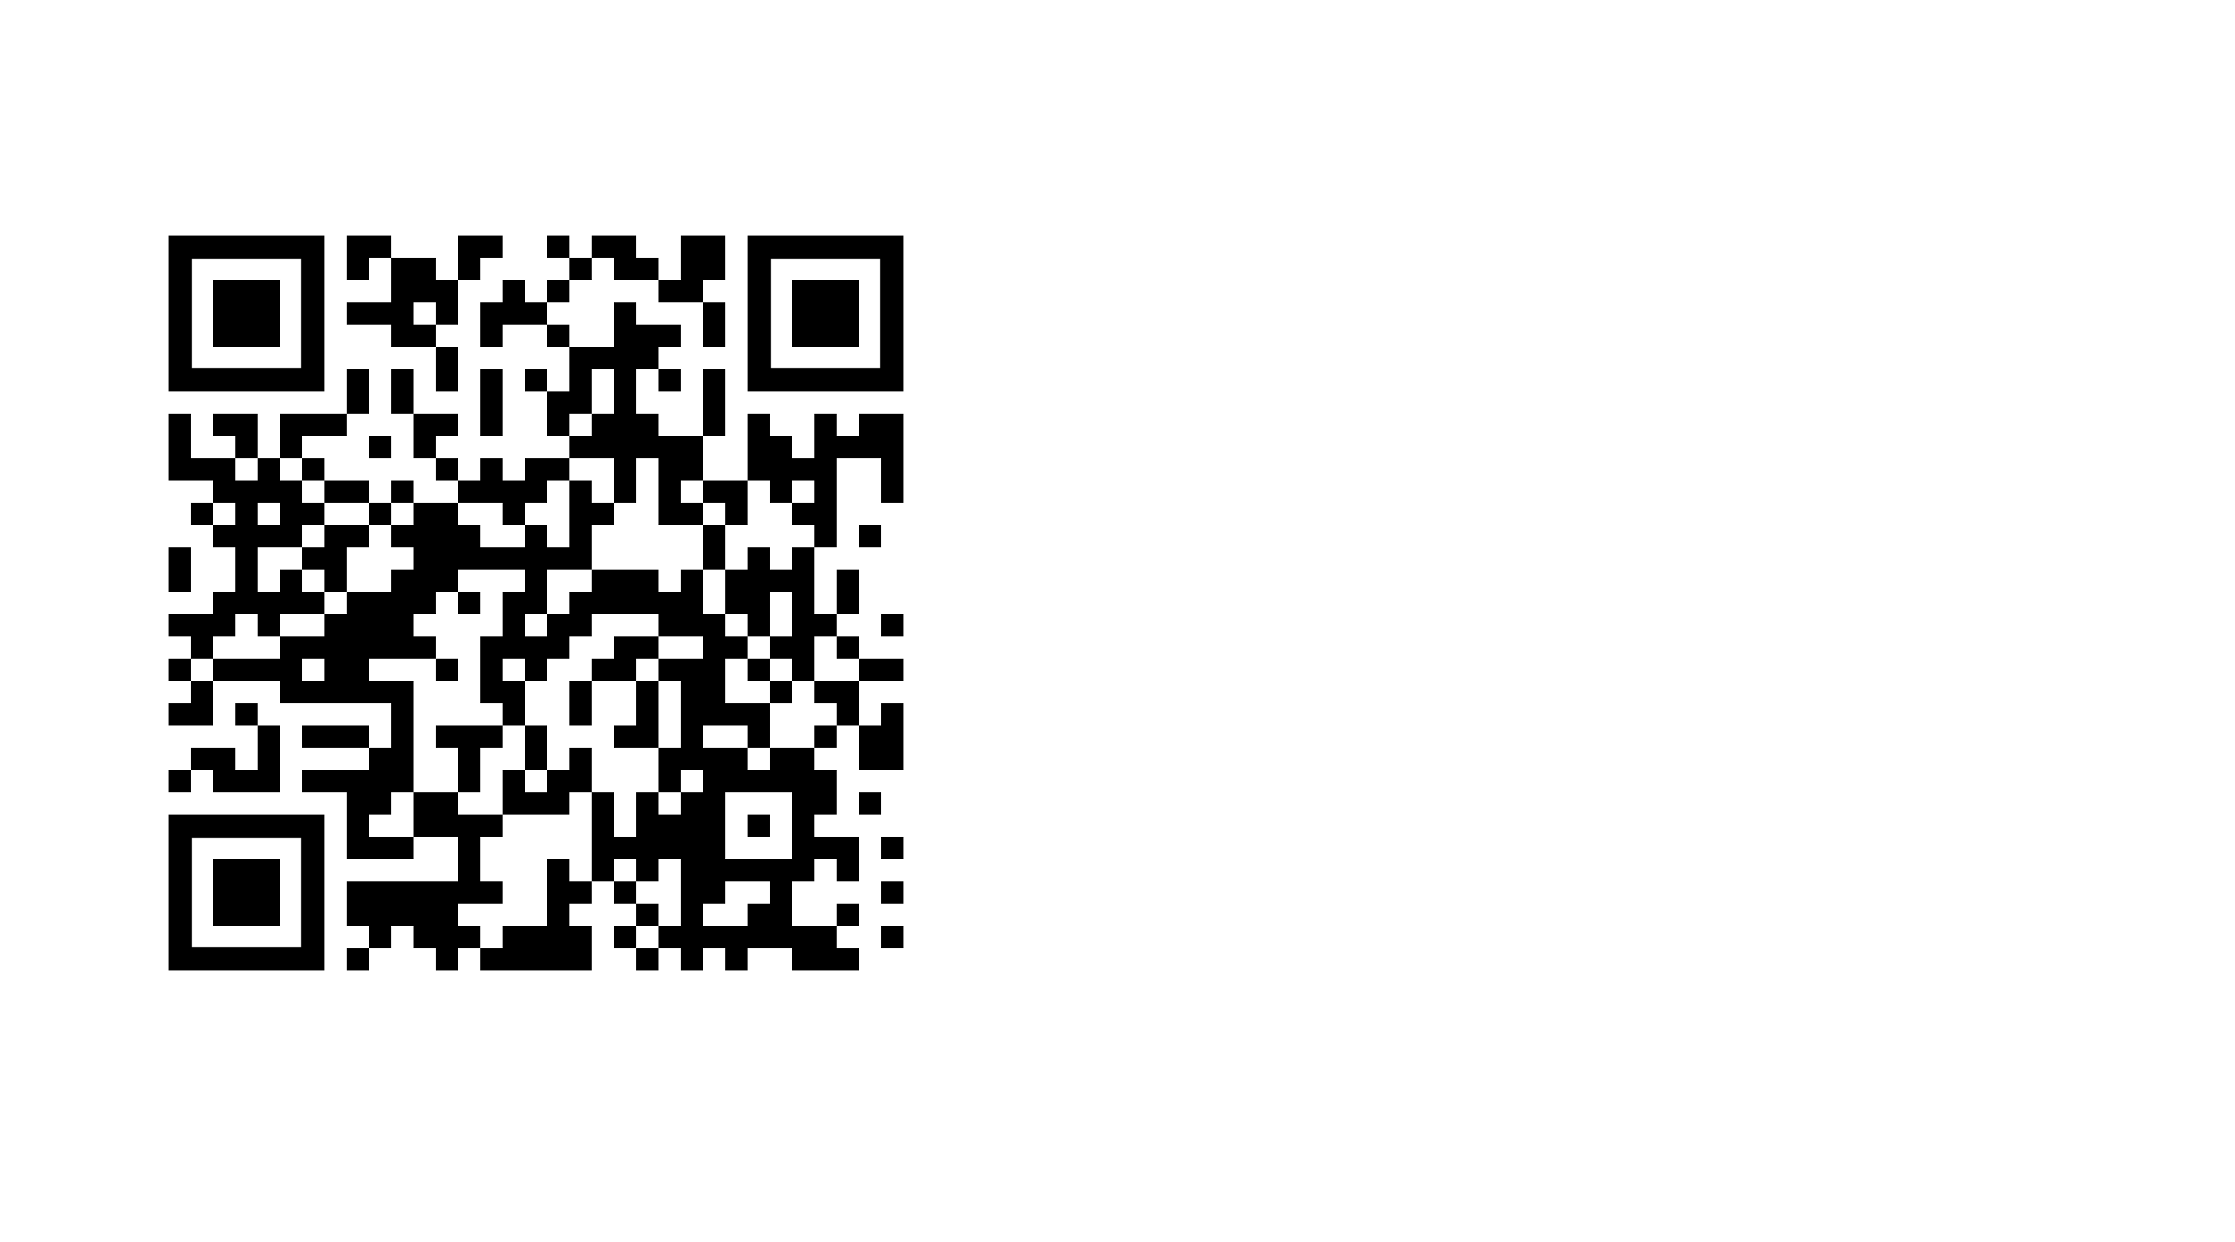